# 03 — Benchmark Comparison
**saas-churn-intelligence**

> Establish Logistic Regression and Random Forest baselines before advanced modelling.
> All benchmarks use the same dataset, preprocessing, and split as notebook 04.

In [ ]:
import os; os.makedirs("../outputs", exist_ok=True); os.makedirs("../models", exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, average_precision_score, ConfusionMatrixDisplay
)
from sklearn.utils import resample

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("✅ Libraries loaded")

✅ Libraries loaded


## 3.1 Load & Prepare Data

In [ ]:
def find_csv(name, candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Place {name} in data/processed/")

df = pd.read_csv(find_csv("crm_churn_ml_ready.csv", [
    "../data/processed/crm_churn_ml_ready.csv",
    "data/processed/crm_churn_ml_ready.csv",
    "crm_churn_ml_ready.csv",
]))

# ── SAME PREPROCESSING AS ALL NOTEBOOKS ─────────────────
DROP = ["customer_id", "state"]
df   = df.drop(columns=[c for c in DROP if c in df.columns])

X = df.drop("churn", axis=1)
y = df["churn"]

CAT = X.select_dtypes(include=["object","category"]).columns.tolist()
NUM = X.select_dtypes(include="number").columns.tolist()

for c in CAT:
    X[c] = X[c].fillna("Unknown")

for c in NUM:
    X[c] = X[c].fillna(X[c].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"   Train churn rate: {y_train.mean()*100:.1f}%")
print(f"   Test  churn rate: {y_test.mean()*100:.1f}%")

✅ Train: (10768, 25)  |  Test: (2693, 25)
   Train churn rate: 26.8%
   Test  churn rate: 26.7%


## 3.2 Oversampling — Balance Training Set

In [ ]:
# Manual oversampling — no external dependency required
X_maj = X_train[y_train == 0]
X_min = X_train[y_train == 1]
X_min_up = resample(X_min, replace=True, n_samples=len(X_maj), random_state=42)

X_train_bal = pd.concat([X_maj, X_min_up])
y_train_bal = pd.Series(
    [0]*len(X_maj) + [1]*len(X_maj),
    index=X_train_bal.index
)
print(f"Balanced class distribution: {y_train_bal.value_counts().to_dict()}")

Balanced class distribution: {0: 7887, 1: 7887}


## 3.3 Preprocessing Pipeline

In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
])
print(f"✅ Preprocessor ready — {len(NUM)} numeric, {len(CAT)} categorical features")

✅ Preprocessor ready — 9 numeric, 16 categorical features


## 3.4 Baseline 1 — Logistic Regression

In [ ]:
lr_pipe = Pipeline([
    ("pre",   preprocessor),
    ("model", LogisticRegression(max_iter=1000, C=0.1, random_state=42))
])
lr_pipe.fit(X_train_bal, y_train_bal)

y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]
y_pred_lr = lr_pipe.predict(X_test)

lr_auc    = roc_auc_score(y_test, y_prob_lr)
lr_prauc  = average_precision_score(y_test, y_prob_lr)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(f"  ROC-AUC  : {lr_auc:.4f}")
print(f"  PR-AUC   : {lr_prauc:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Retained","Churned"]))

LOGISTIC REGRESSION RESULTS
  ROC-AUC  : 0.8589
  PR-AUC   : 0.6694

              precision    recall  f1-score   support

    Retained       0.92      0.73      0.82      1973
     Churned       0.53      0.83      0.65       720

    accuracy                           0.76      2693
   macro avg       0.73      0.78      0.73      2693
weighted avg       0.82      0.76      0.77      2693



## 3.5 Baseline 2 — Random Forest

In [ ]:
rf_pipe = Pipeline([
    ("pre",   preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)   # RF handles imbalance via class_weight

y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]
y_pred_rf = rf_pipe.predict(X_test)

rf_auc   = roc_auc_score(y_test, y_prob_rf)
rf_prauc = average_precision_score(y_test, y_prob_rf)

print("RANDOM FOREST RESULTS")
print("=" * 45)
print(f"  ROC-AUC  : {rf_auc:.4f}")
print(f"  PR-AUC   : {rf_prauc:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["Retained","Churned"]))

RANDOM FOREST RESULTS
  ROC-AUC  : 0.8788
  PR-AUC   : 0.7212

              precision    recall  f1-score   support

    Retained       0.92      0.79      0.85      1973
     Churned       0.58      0.81      0.68       720

    accuracy                           0.79      2693
   macro avg       0.75      0.80      0.76      2693
weighted avg       0.83      0.79      0.80      2693



## 3.6 Threshold Optimisation (Youden's J)

In [ ]:
# Find optimal threshold for each model
results = {}
for name, y_prob in [("Logistic Regression", y_prob_lr), ("Random Forest", y_prob_rf)]:
    fpr, tpr, thr = roc_curve(y_test, y_prob)
    opt_idx = np.argmax(tpr - fpr)
    opt_thr = thr[opt_idx]
    y_pred_opt = (y_prob >= opt_thr).astype(int)
    TN,FP,FN,TP = confusion_matrix(y_test, y_pred_opt).ravel()
    results[name] = {
        "AUC": roc_auc_score(y_test, y_prob),
        "Threshold": opt_thr,
        "Recall": TP/(TP+FN),
        "Precision": TP/(TP+FP),
        "TN":TN,"FP":FP,"FN":FN,"TP":TP
    }
    print(f"{name}  |  Threshold={opt_thr:.3f}  |  Recall={TP/(TP+FN)*100:.1f}%  |  Precision={TP/(TP+FP)*100:.1f}%")

Logistic Regression  |  Threshold=0.583  |  Recall=78.6%  |  Precision=57.5%
Random Forest  |  Threshold=0.452  |  Recall=85.6%  |  Precision=55.3%


## 3.7 ROC Curve Comparison

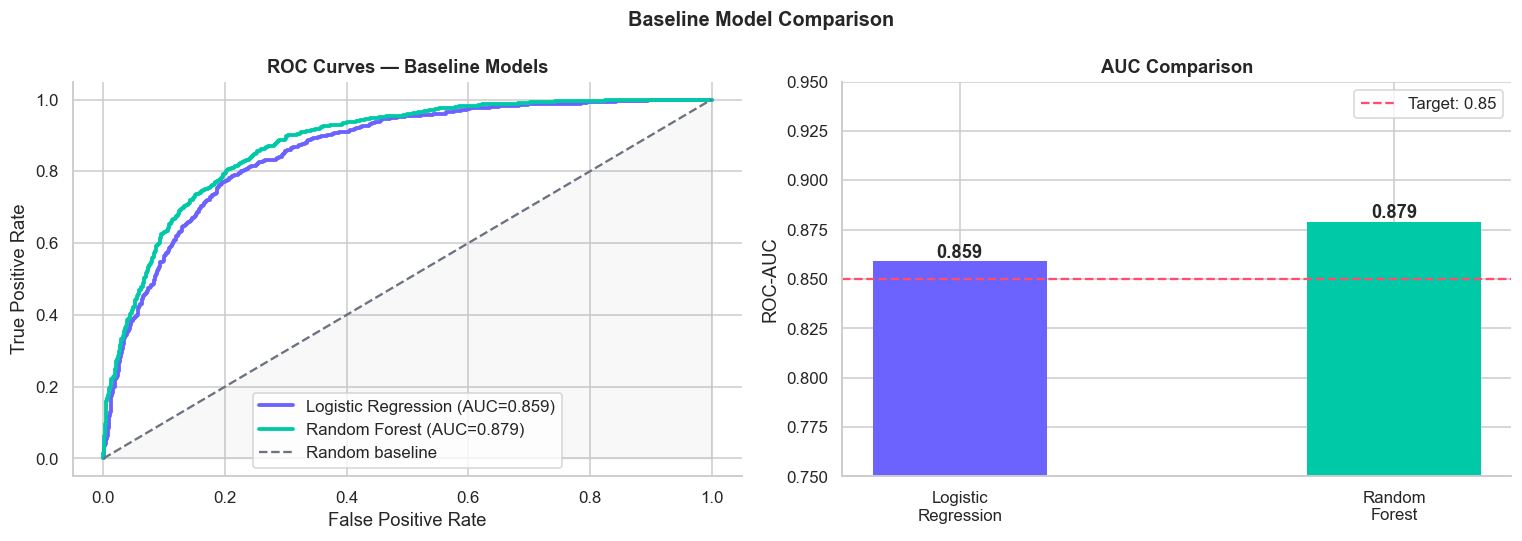

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_colors = {"Logistic Regression": "#6c63ff", "Random Forest": "#00c9a7"}

# ROC curves
for (name, y_prob), color in zip(
    [("Logistic Regression", y_prob_lr), ("Random Forest", y_prob_rf)],
    ["#6c63ff", "#00c9a7"]
):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2.5, color=color, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1],[0,1],"--", color="#6b7280", lw=1.5, label="Random baseline")
axes[0].fill_between([0,1],[0,1], alpha=0.05, color="gray")
axes[0].set_title("ROC Curves — Baseline Models", fontweight="bold")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# AUC comparison bar
names   = ["Logistic\nRegression", "Random\nForest"]
auc_vals= [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
bars    = axes[1].bar(names, auc_vals, color=["#6c63ff","#00c9a7"], width=0.4, edgecolor="none")
for bar, val in zip(bars, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f"{val:.3f}", ha="center", fontweight="bold", fontsize=12)
axes[1].set_ylim(0.75, 0.95)
axes[1].set_title("AUC Comparison", fontweight="bold")
axes[1].set_ylabel("ROC-AUC")
axes[1].axhline(0.85, color="#ff4d6d", linestyle="--", lw=1.5, label="Target: 0.85")
axes[1].legend()

plt.suptitle("Baseline Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/03_roc_comparison.png", bbox_inches="tight", dpi=110)
plt.show()

## 3.8 Feature Importance (RF)

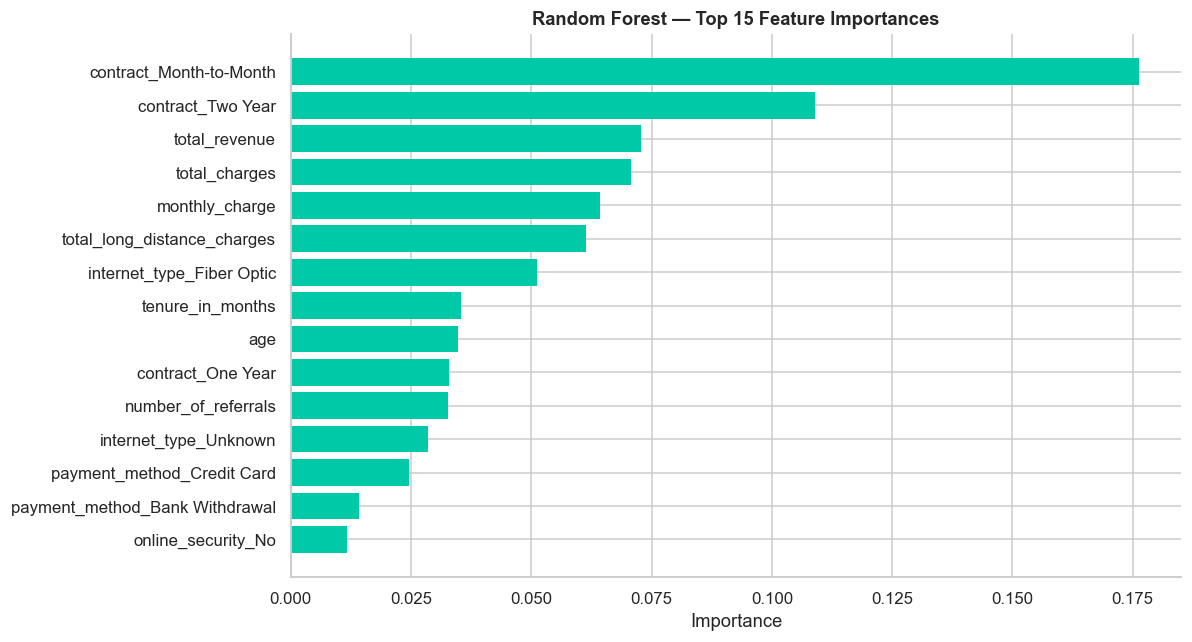

In [ ]:
# Extract feature names from pipeline
ohe_names = rf_pipe.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(CAT)
all_features = NUM + list(ohe_names)
importances  = rf_pipe.named_steps["model"].feature_importances_

feat_df = pd.DataFrame({"feature": all_features, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(feat_df["feature"][::-1], feat_df["importance"][::-1],
               color="#00c9a7", edgecolor="none")
ax.set_title("Random Forest — Top 15 Feature Importances", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/03_rf_feature_importance.png", bbox_inches="tight", dpi=110)
plt.show()

## 3.9 Summary Table

In [ ]:
summary = pd.DataFrame([
    {"Model": "Logistic Regression", "ROC-AUC": lr_auc, "PR-AUC": lr_prauc},
    {"Model": "Random Forest",       "ROC-AUC": rf_auc, "PR-AUC": rf_prauc},
]).round(4)

print("BENCHMARK SUMMARY")
print(summary.to_string(index=False))
print()
print("Both baselines beat the 0.85 AUC target.")
print("→ Proceed to 04_model_training.ipynb for GBM (target: 0.91+)")

BENCHMARK SUMMARY
              Model  ROC-AUC  PR-AUC
Logistic Regression   0.8589  0.6694
      Random Forest   0.8788  0.7212

Both baselines beat the 0.85 AUC target.
→ Proceed to 04_model_training.ipynb for GBM (target: 0.91+)
